### Check the quality of Healthy-Aging_KG and Compare to AD-KG

In [78]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict
import seaborn as sns

In [161]:
health_kg_path = "../data/KG/healthy_aging_kg.pkl"
ad_kg_path = "../data/KG/ad_causal_only.pkl"

def load_graph(kg_path):
    with open(kg_path, 'rb') as f:
        kg = pickle.load(f)
    print(f"Graph has {kg.number_of_nodes()} nodes and {kg.number_of_edges()} edges.")
    return kg

health_kg = load_graph(health_kg_path)
ad_kg = load_graph(ad_kg_path)

Graph has 4338 nodes and 7410 edges.
Graph has 3732 nodes and 13133 edges.


In [162]:
ad_edges_to_remove = []
for src, dst, rel, attr in ad_kg.edges(data=True, keys=True):
    if 'rev' in rel:
        ad_edges_to_remove.append((src,dst, rel))
ad_kg.remove_edges_from(ad_edges_to_remove)
print(ad_kg.number_of_edges())
with open("../data/KG/ad_noreverse_causal.pkl", 'wb') as f:
    pickle.dump(ad_kg, f)

5277


## Extract the proteins nodes in Healthy-KG

In [37]:
nt_mapping = {'composite': 'composite',
 'rxn': 'reaction',
 'sec': 'cell_secretion',
 'reactants': 'reactants',
 'frag': 'fragment',
 'fromLoc': 'from_location',
 'loc': 'location',
 'var': 'variant',
 'r': 'rna',
 'surf': 'cell_surface_expression',
 'act': 'activity',
 'bp': 'bilogical_process',
 'a': 'abundance',
 'fus': 'fusion_protein',
 'pmod': 'pmod',
 'p': 'protein',
 'complex': 'complex',
 'products': 'products',
 'g': 'gene',
 'deg': 'degradation',
 'tloc': 'translocation',
 'toLoc': 'to_location'}
def add_attrs_to_kg(KG:nx.MultiDiGraph, nt_mapping, output:str):
    
    # add node label
    for id, attr in KG.nodes(data=True):
        node_name = attr.get('bel')
        nt = node_name.split('(')[0]
        attr['label'] = nt_mapping[nt]
    #print(attr['label'])

    # add edge triple names (the origin one only has ids)
    for src, dst, rel, attr in KG.edges(data=True, keys=True):
        src_name = KG.nodes[src]['bel']
        dst_name = KG.nodes[dst]['bel']
        rel_type = attr.get('type')
        attr['triple'] = (src_name, rel_type, dst_name)

    with open(output, 'wb') as f:
        pickle.dump(KG, f)

    return KG

In [38]:
kg_health = add_attrs_to_kg(health_kg, nt_mapping, health_kg_path)

In [134]:
potential_proteins = defaultdict(list)
human_proteins = []
human_genes = []
human_rna = []
for node, attrs in kg_health.nodes(data=True):
    label = attrs['label']
    namespace = attrs.get('namespace', None)
    node_id = attrs.get('bel', None)
    name = attrs.get('name', None)
    print(attrs)
    
    if namespace == 'UniProtKB':
        potential_proteins[label].append(node_id)
        if 'HUMAN' in node_id:
            if label == 'protein': human_proteins.append(node_id)
            elif label =='gene': human_genes.append(node_id)
            elif label == 'rna' : human_rna.append(node_id)

{'out_regulates': '["#821:28"]', 'in_transcribed_to': '["#940:19"]', 'involved_genes': '["Bace1"]', 'involved_other': '[]', 'in_increases': '["#690:57", "#693:57"]', 'species': 10090, 'bel': 'r(MGI:"Bace1")', 'namespace': 'MGI', 'name': 'Bace1', 'orientdb_rid': '#221:5', 'pure': True, 'label': 'rna'}
{'out_regulates': '["#811:0", "#812:0", "#817:0", "#826:0", "#829:0", "#810:1", "#811:1", "#812:1", "#814:1", "#815:1", "#816:1", "#825:1", "#817:3", "#818:3", "#824:3", "#824:4", "#826:32", "#821:34", "#822:34", "#817:35", "#818:35", "#819:35", "#810:41"]', 'out_increases': '["#690:7", "#690:45", "#690:64", "#690:78", "#691:7", "#691:8", "#691:45", "#692:5", "#692:7", "#692:64", "#693:7", "#694:8", "#695:64", "#696:34", "#696:77", "#697:34", "#697:65", "#698:34", "#699:65", "#700:7", "#700:44", "#700:64", "#700:67", "#701:64", "#701:66", "#701:67", "#702:44", "#702:66", "#702:67", "#704:9", "#704:26", "#704:44", "#705:44", "#705:67", "#706:44", "#706:64", "#707:44", "#707:64", "#708:44", 

In [55]:
print('Number of Human Proteins:',len(human_proteins))
print('Number of Human Genes:',len(human_genes))
print('Number of Human RNA:',len(human_rna))

Number of Human Proteins: 484
Number of Human Genes: 264
Number of Human RNA: 264


#### Node types and edge types

In [142]:
def count_kg(KG):
    node_types = defaultdict(list)
    edge_types = defaultdict(list)

    for n, attrs in KG.nodes(data=True):
        node_type = attrs['label']
        node_id = attrs.get('bel', None)
        node_types[node_type].append(node_id)

    for src, dst, rel, attr in KG.edges(data=True, keys=True):
        src_type = KG.nodes[src]['label']
        dst_type = KG.nodes[dst]['label']
        src_name = KG.nodes[src]['bel']
        dst_name = KG.nodes[dst]['bel']
        rel_type = attr.get('type')
        edge_type = (src_type, rel_type, dst_type)
        edge_types[edge_type].append((src_name,dst_name))
    return node_types, edge_types
node_counts, edge_counts = count_kg(kg_health) 

In [154]:
df_edge_type = pd.DataFrame({'EdgeType': list(edge_counts.keys()),
                             'Count': [len(v) for v in edge_counts.values()]})
df_node_type = pd.DataFrame({'NodeType': list(node_counts.keys()),
                             'Count': [len(v) for v in node_counts.values()]})
df_node_type = df_node_type.sort_values(by='Count', ascending=False)
df_edge_type = df_edge_type.sort_values(by='Count', ascending= False)
df_edge_type.to_csv("../data/healthy_kg_edge_type.csv", sep='\t', index_label=0)

In [156]:
df_node_type

,NodeType,Count
7,protein,944
13,gene,680
0,rna,662
1,abundance,385
4,bilogical_process,369
10,complex,299
6,activity,217
17,fragment,163
2,composite,138
3,translocation,107


In [51]:
print(len(potential_proteins))
for k,v in potential_proteins.items():
    print(k, len(v))
print()
potential_proteins

3
protein 826
gene 497
rna 497



defaultdict(list,
            {'protein': ['p(UniProtKB:"IGF1_HUMAN")',
              'p(UniProtKB:"EAA2_RAT")',
              'p(UniProtKB:"A4_MOUSE",frag("18_687"))',
              'p(UniProtKB:"PSN1_MOUSE")',
              'p(UniProtKB:"SRS10_HUMAN")',
              'p(UniProtKB:"ADA17_MOUSE")',
              'p(UniProtKB:"A4_HUMAN",frag("?","APP extracellular domain"))',
              'p(UniProtKB:"GAB2_HUMAN",frag("6_117"))',
              'p(UniProtKB:"LRP1_MOUSE")',
              'p(UniProtKB:"IRS1_HUMAN",pmod(Ph,Y))',
              'p(UniProtKB:"CLU_HUMAN")',
              'p(UniProtKB:"GAB2_HUMAN")',
              'p(UniProtKB:"A4_RAT",pmod(Ph,T,668))',
              'p(UniProtKB:"CADH1_HUMAN")',
              'p(UniProtKB:"IRS2_HUMAN",pmod(Ph,Y))',
              'p(UniProtKB:"ADA10_MOUSE")',
              'p(UniProtKB:"CASP6_HUMAN")',
              'p(UniProtKB:"A4_MOUSE",pmod(Ph,Y,682))',
              'p(UniProtKB:"SCRB1_HUMAN",frag("?","extracellular domain"))',
          

In [69]:
import re
def get_name_species(text:str, pattern:str = '(UniProtKB:"(\w+)_(\w+)")'):
    match = re.search(pattern, text)
    if match:
        #print(match.group())
        name = match.group(2)
        species = match.group(3)
        return name, species
    else:
        print('No match found.')

get_name_species('r(UniProtKB:"CHIP_MOUSE"')

('CHIP', 'MOUSE')

In [106]:
uniprotkb = {}
for k,v in potential_proteins.items():
    uniprotkb[k]=defaultdict(list)
    for n in v:
        name, species = get_name_species(n)
        uniprotkb[k][species].append(name)

for k,v in uniprotkb.items():
    print(k)
    for sp, prs in v.items():
        print(sp,len(prs))
    print()
    break
# Flattening the dictionary for Seaborn
rows = []
for molecule, species_dict in uniprotkb.items():
    for species, proteins in species_dict.items():
        rows.append({'Molecule': molecule, 'Species': species, 'Proteins': proteins, 'Count': len(proteins)})

df_healthy = pd.DataFrame(rows)
df_healthy

protein
HUMAN 484
RAT 85
MOUSE 256
SHEEP 1



,Molecule,Species,Proteins,Count
0,protein,HUMAN,"[IGF1, SRS10, A4, GAB2, IRS1, CLU, GAB2, CADH1...",484
1,protein,RAT,"[EAA2, A4, SODM, A4, TGFB1, A4, ITB1, RELN, CR...",85
2,protein,MOUSE,"[A4, PSN1, ADA17, LRP1, ADA10, A4, S100B, CBPE...",256
3,protein,SHEEP,[CLUS],1
4,gene,HUMAN,"[CFAI, ACM1, BCL2, GAB1, STK11, SRC, CLU, NMDE...",264
5,gene,RAT,"[GNA11, ALBU, CP2E1, CISY, BCL2, MK10, CRIP1, ...",53
6,gene,MOUSE,"[CDC42, PON1, GSK3A, KGP2, BDNF, DLG4, SORL, U...",179
7,gene,SHEEP,[CLUS],1
8,rna,HUMAN,"[CFAI, ACM1, BCL2, GAB1, STK11, SRC, CLU, NMDE...",264
9,rna,RAT,"[GNA11, ALBU, CP2E1, CISY, BCL2, MK10, CRIP1, ...",53


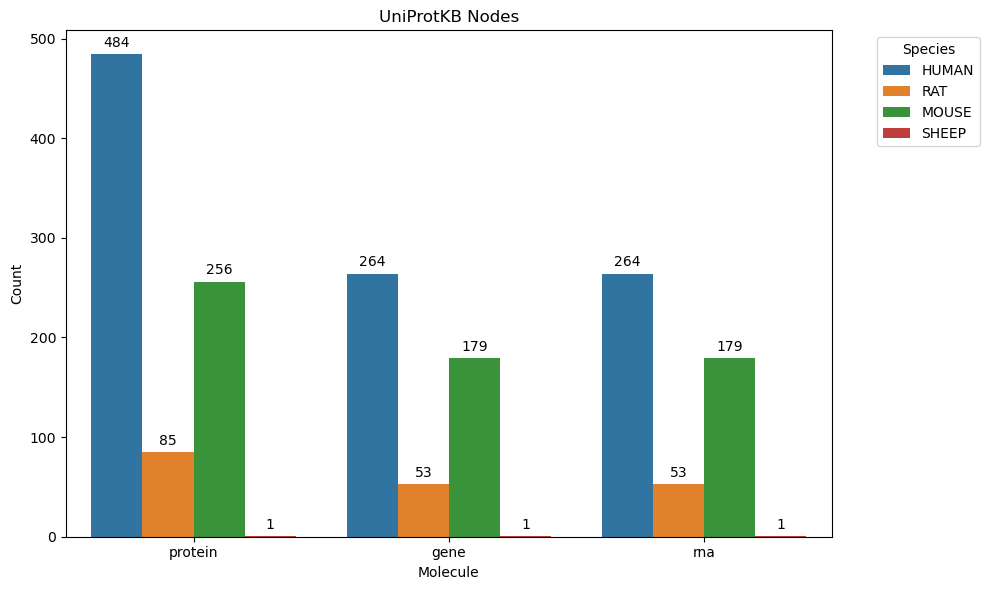

In [108]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_healthy, ax=ax, x='Molecule', y='Count', hue='Species')

# Iterate through the bar containers and add labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('UniProtKB Nodes')
plt.ylabel('Count') 
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Extract protein nodes in AD-KG

In [90]:
hgnc = defaultdict(list)
for n, attr in ad_kg.nodes(data=True):
    #print(n)
    label = attr.get('label', None)
    #print(label)
    if attr.get('namespace', None) == 'HGNC':
        hgnc[label].append(n)
hgnc.keys()

dict_keys(['Gene', 'MicroRna', 'Protein', 'Rna'])

In [111]:
def get_hgnc_name(text, pattern:str='(HGNC:"(\w+)")'):
    match = re.search(pattern, text)
    if match:
        name = match.group(2)
        #print(name)
        return name
    else:
        return None

hgnc_names = defaultdict(list)
for k, v in hgnc.items():
    for i in v:
        name = get_hgnc_name(i)
        hgnc_names[k].append(name)


# Flattening the dictionary for Seaborn plot
hgnc_rows = []
for molecule, names in hgnc_names.items():
    hgnc_rows.append({'Molecule': molecule, 'Name': names, 'Count': len(names)})

df_ad = pd.DataFrame(hgnc_rows)
df_ad

,Molecule,Name,Count
0,Gene,"[BDNF, TP53, PPP1CC, VLDLR, SLC1A2, PTK2B, PPA...",128
1,MicroRna,"[MIR132, MIR195, MIR130A, MIR137, MIR106B, MIR...",45
2,Protein,"[GRIN2B, GRIN2D, GRIA1, GRM2, IL6, TNF, IL2, T...",1006
3,Rna,"[GSK3B, IL6, INSR, AGER, GRIA2, BACE1, IL1B, T...",86


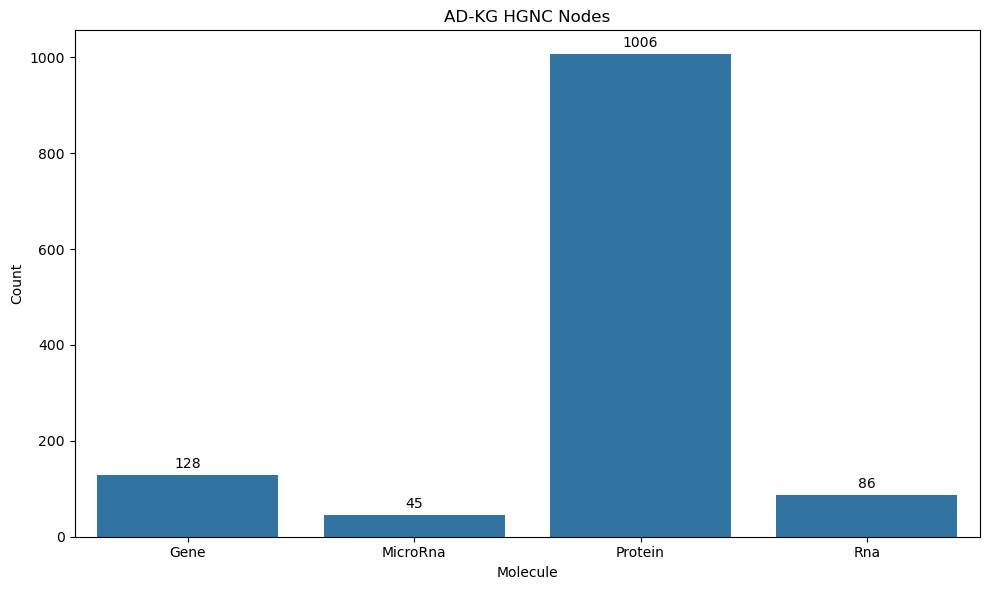

In [113]:
# barplot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_ad, ax=ax, x='Molecule', y='Count')

# Iterate through the bar containers and add labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('AD-KG HGNC Nodes')
plt.ylabel('Count') 
plt.tight_layout()
plt.show()

## Comparison of Proteins in Healthy-KG, AD-KG and GeneExpression

In [117]:
# GeneExpression proteins
exp = pd.read_csv("../data/adni_gene_cleaned.csv", index_col=0).T
exp_proteins = set(exp.columns)
len(exp_proteins)

19100

In [122]:
# healthy proteins 
healthy_prs = set(uniprotkb['protein']['HUMAN'])
print(len(healthy_prs))

# ad proteins
ad_prs = set(hgnc_names['Protein'])
print(len(ad_prs))

264
778


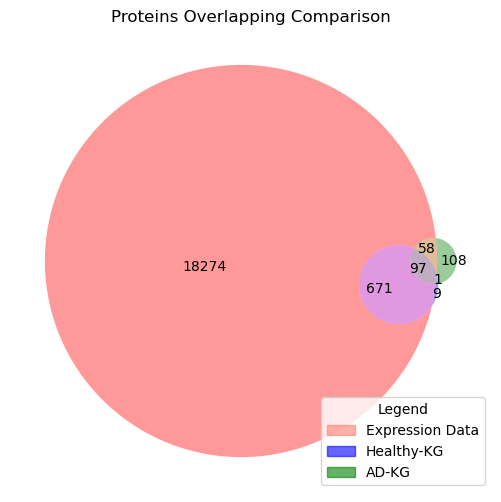

In [130]:
from matplotlib_venn import venn3, venn2
import matplotlib.patches as mpatches

plt.figure(figsize=(10,6))
venn = venn3((exp_proteins, healthy_prs, ad_prs), set_labels=('', '', ''))
red_patch = mpatches.Patch(color='salmon', alpha=0.6, label='Expression Data')
blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Healthy-KG')
green_patch = mpatches.Patch(color='green', alpha=0.6, label='AD-KG')

# 2. Add the legend to the plot
plt.legend(handles=[red_patch, blue_patch, green_patch], loc='lower right', title="Legend")
plt.title('Proteins Overlapping Comparison')
plt.show()

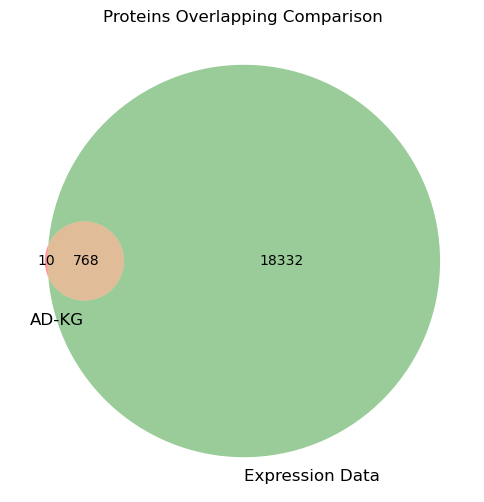

In [133]:
plt.figure(figsize=(10,6))
venn = venn2((ad_prs, exp_proteins), set_labels=('AD-KG', 'Expression Data'))
#plt.legend(handles=[red_patch, blue_patch, green_patch], loc='lower right', title="Legend")
plt.title('Proteins Overlapping Comparison')
plt.show()